# CIFAR-10 Functa Perturbation Amplification

Measures how a **small image perturbation** propagates through the **production functa pipeline**:

1. **φ encoding** — same as `makeset.py`: SGD, `lr=0.01`, **3 inner steps**, φ init from zero
2. **Clean φ** — optionally loaded from the saved **test functaset** (what the CNN was trained on)
3. **Spatial SIREN** — reconstruction sensitivity per layer
4. **CNN classifier** — logit / prediction change

**Default run:** vanilla e512 backbone + full functaset CNN, to guide **soft-Lipschitz cap** choices for the next training run.

Outputs: `runs/<SLUG>/perturbation_analysis/<EVAL_NAME>/`


In [1]:
# 0. Configuration
from pathlib import Path

REPO_ROOT = Path("/home/omarg/SIREN_Vista")
DATA_ROOT = Path("/home/omarg/data")

# --- Vanilla baseline (e512, inner3 makeset) — use this to pick soft-lip caps ---
MODEL_VARIANT = "vanilla"
SLUG = "functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000"

CKPT_PATH = REPO_ROOT / "model_cifar10" / SLUG / "modSiren.pth"
CLF_PATH = REPO_ROOT / "runs" / SLUG / "cifar10_cnn_classifier" / "best_classifier.pth"
FUNCTASET_TEST_PATH = REPO_ROOT / "runs" / SLUG / "functaset" / f"{SLUG}_test.pkl"

EVAL_NAME = "vanilla_inner3_makeset_match"
OUT_ROOT = REPO_ROOT / "runs" / SLUG / "perturbation_analysis" / EVAL_NAME
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CUDA_DEVICE_ID = 0
PREFER_DEVICE = "cuda"  # resolved to DEVICE in the imports cell (after torch loads)

USE_CLASSIFIER = True

# Match makeset / meta-training inner loop (NOT 200-step diagnostic fitting)
INNER_STEPS = 3
INNER_LR = 0.01
INNER_OPTIM = "sgd"  # sgd | adam
GRAD_CLIP_NORM = 1.0

# Clean φ from saved functaset = exactly what the classifier saw
USE_FUNCTASET_PHI_CLEAN = True
# Perturbed images: refit φ from zero (same as makeset per image)
PERT_INIT_FROM_CLEAN = False

IMAGE_INDICES = [8138, 0, 1, 2]
EPS_LIST = [0, 1, 2, 4, 8, 16]  # in units of 1/255
PERT_DIRECTION = "uniform"  # uniform | random_sign
PERT_SEED = 0

print("Configured:", OUT_ROOT)
print("  variant:", MODEL_VARIANT)
print("  backbone:", CKPT_PATH)
print("  classifier:", CLF_PATH if USE_CLASSIFIER else "(disabled)")
print("  functaset test:", FUNCTASET_TEST_PATH if USE_FUNCTASET_PHI_CLEAN else "(fit clean φ)")
print(f"  inner fit: {INNER_STEPS} x {INNER_OPTIM} lr={INNER_LR}")

Configured: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/perturbation_analysis/vanilla_inner3_makeset_match
  variant: vanilla
  backbone: /home/omarg/SIREN_Vista/model_cifar10/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/modSiren.pth
  classifier: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/cifar10_cnn_classifier/best_classifier.pth
  functaset test: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/functaset/functa_like_cifar10_spatial_paper_siren_h256_md

In [2]:
import os
import sys
from pathlib import Path
from types import SimpleNamespace

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display
from torchvision.datasets import CIFAR10
import torchvision.transforms as T


def resolve_repo_root():
    """Find SIREN_Vista root whether the kernel cwd is repo root or notebooks/."""
    candidates = []
    if "REPO_ROOT" in globals():
        candidates.append(Path(REPO_ROOT))
    here = Path.cwd().resolve()
    candidates.extend([here, here.parent, Path("/home/omarg/SIREN_Vista")])
    for root in candidates:
        if (root / "SIREN.py").is_file() and (root / "variants").is_dir():
            return root
    raise FileNotFoundError(
        "Could not find SIREN_Vista repo root (missing SIREN.py). "
        "Run the config cell first or cd to the repo / notebooks folder."
    )


REPO_ROOT = resolve_repo_root()
_repo = str(REPO_ROOT.resolve())
if _repo in sys.path:
    sys.path.remove(_repo)
sys.path.insert(0, _repo)
print("repo root:", REPO_ROOT)

# Drop cached `variants` (stale/partial imports break variants.build)
import importlib
for _key in list(sys.modules):
    if _key == "variants" or _key.startswith("variants."):
        del sys.modules[_key]

variants = importlib.import_module("variants")
if not hasattr(variants, "build"):
    raise ImportError(
        f"Wrong variants module loaded from {getattr(variants, '__file__', '?')}; "
        f"expected {REPO_ROOT / 'variants' / '__init__.py'}"
    )
print("variants:", variants.__file__, "registered:", variants.available())
from SIREN import (
    ModulatedFINER,
    ModulatedFourierLSA,
    ModulatedFourierSIREN,
    ModulatedSIREN,
    SpatialModulatedINR,
)
from train_classifier import (
    SpatialPhiCNN,
    SpatialFunctaTransformer,
    Classifier,
    _prepare_modulations,
    apply_phi_normalization,
)

if PREFER_DEVICE == "cuda" and torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("device:", DEVICE)


repo root: /home/omarg/SIREN_Vista
variants: /home/omarg/SIREN_Vista/variants/__init__.py registered: ['soft_lipschitz', 'vanilla']
device: cuda


In [3]:
def _variant_args_from_ckpt(ckpt):
    va = ckpt.get("variant_args", {}) or {}
    return SimpleNamespace(
        variant=ckpt.get("variant", "vanilla"),
        soft_lip_cap=va.get("soft_lip_cap", 1.0),
        soft_lip_lambda=va.get("soft_lip_lambda", 1e-2),
        soft_lip_apply_to=va.get("soft_lip_apply_to", "sine_and_readout"),
        soft_lip_power_iters=va.get("soft_lip_power_iters", 1),
        soft_lip_skip_first=va.get("soft_lip_skip_first", False),
        soft_lip_reference_checkpoint=va.get("soft_lip_reference_checkpoint"),
        soft_lip_reference_scale=va.get("soft_lip_reference_scale", 0.90),
    )


def build_model_from_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model_args = ckpt.get("model_args", {}) or {}
    state = ckpt.get("state_dict", {}) or {}
    inr_type = model_args.get("inr_type", "siren")
    if inr_type == "siren" and "fourier.B" in state:
        inr_type = "fourier_siren"

    h = model_args.get("height", 32)
    w = model_args.get("width", 32)
    c = model_args.get("out_features", 3)
    hidden_dim = model_args.get("hidden_dim", 256)
    depth = model_args.get("depth", 6)
    mod_dim = model_args.get("mod_dim", 1024)
    freq = float(model_args.get("freq", 10.0))

    is_spatial = bool(model_args.get("spatial_modulation", False)) or bool(model_args.get("is_spatial", False))
    if is_spatial:
        model = SpatialModulatedINR(
            height=h, width=w, hidden_features=hidden_dim, num_layers=depth,
            latent_spatial_dim=model_args.get("latent_spatial_dim", 8),
            latent_dim=model_args.get("latent_dim", 16),
            base_inr_type=inr_type, spatial_interp=model_args.get("spatial_interp", "nearest"),
            use_local_coords=bool(model_args.get("use_local_coords", True)),
            modulation_type=model_args.get("modulation_type", "shift"),
            freq=freq, device=device, out_features=c,
            fourier_num_freqs=model_args.get("fourier_num_freqs", 64),
            fourier_sigma=model_args.get("fourier_sigma", 10.0),
            fourier_include_input=bool(model_args.get("fourier_include_input", False)),
            first_bias_scale=model_args.get("finer_first_bias_scale"),
            scale_req_grad=bool(model_args.get("finer_scale_req_grad", False)),
            lsa_num_harmonics=model_args.get("lsa_num_harmonics", 8),
            lsa_init_scale=model_args.get("lsa_init_scale", 1e-3),
            lsa_include_linear=bool(model_args.get("lsa_include_linear", True)),
        )
    elif inr_type == "fourier_siren":
        nf = model_args.get("fourier_num_freqs") or (int(state["fourier.B"].shape[0]) if "fourier.B" in state else 64)
        model = ModulatedFourierSIREN(
            height=h, width=w, hidden_features=hidden_dim, num_layers=depth, modul_features=mod_dim,
            device=device, out_features=c, fourier_num_freqs=nf,
            fourier_sigma=model_args.get("fourier_sigma", 10.0),
            fourier_include_input=bool(model_args.get("fourier_include_input", False)), freq=freq,
        )
    elif inr_type == "finer":
        model = ModulatedFINER(
            height=h, width=w, hidden_features=hidden_dim, num_layers=depth, modul_features=mod_dim,
            device=device, out_features=c, freq=model_args.get("finer_freq", freq),
            first_bias_scale=model_args.get("finer_first_bias_scale", 1.0),
            scale_req_grad=bool(model_args.get("finer_scale_req_grad", False)),
        )
    else:
        model = ModulatedSIREN(height=h, width=w, hidden_features=hidden_dim, num_layers=depth,
            modul_features=mod_dim, device=device, out_features=c, freq=freq)

    model = variants.build(ckpt.get("variant", "vanilla"), model, _variant_args_from_ckpt(ckpt))
    model.load_state_dict(state)
    model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, ckpt, model_args


def load_classifier(clf_path, device):
    ckpt = torch.load(clf_path, map_location=device)
    clf_type = ckpt.get("classifier_type", "mlp")
    state = ckpt.get("state_dict", ckpt)

    if clf_type == "cnn":
        clf = SpatialPhiCNN(
            in_channels=int(ckpt.get("latent_dim", 16)),
            num_classes=10,
            width=int(ckpt.get("cnn_width", 128)),
            dropout=float(ckpt.get("dropout", 0.1)),
        )
    elif clf_type == "mlp":
        clf = Classifier(
            width=int(ckpt.get("cwidth", 512)),
            depth=int(ckpt.get("cdepth", 3)),
            in_features=int(ckpt.get("mod_dim", 512)),
            num_classes=10,
            dropout=float(ckpt.get("dropout", 0.0)),
        )
    else:
        raise ValueError(f"Unsupported classifier_type={clf_type}")

    clf.load_state_dict(state)
    clf.to(device)
    clf.eval()
    for p in clf.parameters():
        p.requires_grad_(False)

    clf._clf_type = clf_type
    clf._latent_spatial_dim = ckpt.get("latent_spatial_dim")
    clf._latent_dim = ckpt.get("latent_dim")
    if ckpt.get("phi_mean") is not None and ckpt.get("phi_std") is not None:
        clf._phi_mean = ckpt["phi_mean"].to(device)
        clf._phi_std = ckpt["phi_std"].to(device).clamp_min(1e-6)
    else:
        clf._phi_mean = None
        clf._phi_std = None
    return clf, ckpt


def image_to_target(img_chw, device):
    """(3, H, W) -> (H*W, 3) on device."""
    return img_chw.to(device).float().permute(1, 2, 0).reshape(-1, img_chw.shape[0])


def forward_with_phi(model, phi):
    """SIREN output reshaped to (H*W, C) for pixel-wise MSE."""
    return model(phi).view(model.height * model.width, model.out_features)


def fit_phi(model, image_chw, steps=None, lr=None, init_phi=None, inner_optim=None, grad_clip_norm=None):
    """Makeset-style inner fit: φ from zero (unless init_phi), SGD/Adam, optional grad clip."""
    steps = INNER_STEPS if steps is None else steps
    lr = INNER_LR if lr is None else lr
    inner_optim = INNER_OPTIM if inner_optim is None else inner_optim
    grad_clip_norm = GRAD_CLIP_NORM if grad_clip_norm is None else grad_clip_norm

    target = image_to_target(image_chw, DEVICE)
    phi = init_phi.clone().detach() if init_phi is not None else model.init_phi(device=DEVICE).float()
    phi.requires_grad_(True)

    if inner_optim == "sgd":
        opt = optim.SGD([phi], lr=lr)
    elif inner_optim == "adam":
        opt = optim.Adam([phi], lr=lr)
    else:
        raise ValueError(f"Unknown inner_optim={inner_optim}")

    for _ in range(steps):
        opt.zero_grad()
        loss = F.mse_loss(forward_with_phi(model, phi), target)
        loss.backward()
        if grad_clip_norm is not None and grad_clip_norm > 0:
            torch.nn.utils.clip_grad_norm_([phi], grad_clip_norm)
        opt.step()
    return phi.detach()


def get_functaset_phi(functaset, image_idx):
    """φ stored in makeset pickles under key 'modul'."""
    entry = functaset[int(image_idx)]
    return torch.tensor(entry["modul"], device=DEVICE, dtype=torch.float32)


def make_linf_delta(shape_chw, eps, direction="uniform", seed=0):
    rng = np.random.default_rng(seed)
    if direction == "uniform":
        delta = rng.uniform(-1.0, 1.0, size=shape_chw)
    else:
        delta = rng.standard_normal(size=shape_chw)
    delta = torch.from_numpy(delta.astype(np.float32))
    delta = delta / (delta.abs().max() + 1e-8) * eps
    return delta


def phi_to_classifier_input(phi, clf, model_args):
    dev = next(clf.parameters()).device
    x = (phi.unsqueeze(0) if phi.dim() == 3 else phi).to(dev)
    if clf._clf_type == "cnn":
        s, c = model_args.get("latent_spatial_dim", 8), model_args.get("latent_dim", 16)
        if x.dim() == 2:
            x = x.view(1, s, s, c)
        return _prepare_modulations(x, "cnn", s, c)
    if clf._clf_type == "mlp":
        return x.reshape(1, -1) if x.dim() > 2 else x
    if clf._clf_type == "vit":
        return x.reshape(1, -1, x.size(-1))
    raise ValueError(f"Unknown clf type {clf._clf_type}")


def apply_norm(clf, x):
    if getattr(clf, "_phi_mean", None) is not None:
        return (x - clf._phi_mean) / clf._phi_std
    return x

In [4]:
# 1. Load backbone + classifier
if DEVICE == "cuda":
    torch.cuda.set_device(CUDA_DEVICE_ID)

model, ckpt, model_args = build_model_from_checkpoint(CKPT_PATH, DEVICE)
clf = None
clf_ckpt = None
if USE_CLASSIFIER and CLF_PATH.exists():
    clf, clf_ckpt = load_classifier(CLF_PATH, DEVICE)
    print("classifier:", clf._clf_type)
else:
    print("classifier: skipped or missing")

cifar_test = CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=T.ToTensor())
print("test set size:", len(cifar_test))

functaset_test = None
if USE_FUNCTASET_PHI_CLEAN:
    if not FUNCTASET_TEST_PATH.exists():
        raise FileNotFoundError(f"Functaset not found: {FUNCTASET_TEST_PATH}")
    functaset_test = joblib.load(FUNCTASET_TEST_PATH)
    print("functaset test:", len(functaset_test), "entries; phi key:", functaset_test[0].get("phi_shape"))

classifier: cnn
Files already downloaded and verified
test set size: 10000
functaset test: 10000 entries; phi key: (8, 8, 16)


In [5]:
def measure_perturbation_amplification(model, clf, image_chw, label, eps, model_args, image_idx, *,
                                       functaset_test=None,
                                       pert_init_from_clean=None,
                                       pert_direction=None, pert_seed=None):
    """Trace image perturbation through makeset-matched φ fit, SIREN, and classifier."""
    pert_init_from_clean = PERT_INIT_FROM_CLEAN if pert_init_from_clean is None else pert_init_from_clean
    pert_direction = PERT_DIRECTION if pert_direction is None else pert_direction
    pert_seed = PERT_SEED if pert_seed is None else pert_seed

    eps_val = eps / 255.0
    delta = make_linf_delta(tuple(image_chw.shape), eps_val, direction=pert_direction, seed=pert_seed)
    x_clean = image_chw.clamp(0, 1)
    x_pert = (x_clean + delta).clamp(0, 1)
    delta_eff = (x_pert - x_clean).detach()

    if USE_FUNCTASET_PHI_CLEAN and functaset_test is not None:
        phi_clean = get_functaset_phi(functaset_test, image_idx)
        phi_clean_source = "functaset"
    else:
        phi_clean = fit_phi(model, x_clean)
        phi_clean_source = f"fit_{INNER_STEPS}step"

    init = phi_clean if pert_init_from_clean else None
    phi_pert = fit_phi(model, x_pert, init_phi=init)
    if eps == 0:
        phi_pert = phi_clean

    with torch.no_grad():
        recon_clean = forward_with_phi(model, phi_clean)
        recon_pert = forward_with_phi(model, phi_pert)
        target_clean = image_to_target(x_clean, DEVICE)

    d_phi = (phi_pert - phi_clean).flatten()
    d_recon = (recon_pert - recon_clean).flatten()

    img_linf = delta_eff.abs().max().item()
    img_l2 = delta_eff.flatten().norm().item()
    phi_l2 = d_phi.norm().item()
    recon_l2 = d_recon.norm().item()
    recon_mse_clean = F.mse_loss(recon_clean, target_clean).item()
    recon_mse_pert = F.mse_loss(recon_pert, image_to_target(x_pert, DEVICE)).item()

    row = {
        "label": int(label),
        "image_idx": int(image_idx),
        "phi_clean_source": phi_clean_source,
        "inner_steps": INNER_STEPS,
        "eps": int(eps),
        "img_linf": img_linf,
        "img_l2": img_l2,
        "phi_l2": phi_l2,
        "recon_l2": recon_l2,
        "recon_mse_clean": recon_mse_clean,
        "recon_mse_pert": recon_mse_pert,
        "amp_phi_over_img_l2": phi_l2 / (img_l2 + 1e-12),
        "amp_recon_over_img_l2": recon_l2 / (img_l2 + 1e-12),
        "amp_recon_over_phi_l2": recon_l2 / (phi_l2 + 1e-12),
    }

    if clf is not None:
        with torch.no_grad():
            x0 = apply_norm(clf, phi_to_classifier_input(phi_clean, clf, model_args))
            x1 = apply_norm(clf, phi_to_classifier_input(phi_pert, clf, model_args))
            log0 = clf(x0)
            log1 = clf(x1)
            d_log = (log1 - log0).flatten()
            prob0 = log0.softmax(-1)
            prob1 = log1.softmax(-1)
        row.update({
            "logit_l2": d_log.norm().item(),
            "prob_l1": (prob1 - prob0).abs().sum().item(),
            "pred_clean": int(log0.argmax(-1).item()),
            "pred_pert": int(log1.argmax(-1).item()),
            "pred_flip": int(log0.argmax(-1).item() != log1.argmax(-1).item()),
            "amp_logit_over_img_l2": row["logit_l2"] / (img_l2 + 1e-12) if "logit_l2" in row else None,
        })
        row["amp_logit_over_img_l2"] = row["logit_l2"] / (img_l2 + 1e-12)
        row["amp_logit_over_phi_l2"] = row["logit_l2"] / (phi_l2 + 1e-12)

    return row, {
        "x_clean": x_clean, "x_pert": x_pert, "delta": delta_eff,
        "phi_clean": phi_clean, "phi_pert": phi_pert,
        "recon_clean": recon_clean, "recon_pert": recon_pert,
    }


def run_amplification_sweep(model, clf, dataset, indices, eps_list, model_args, out_root, functaset_test=None):
    rows = []
    for idx in indices:
        img, label = dataset[idx]
        for eps in eps_list:
            row, _ = measure_perturbation_amplification(
                model, clf, img, label, eps, model_args, idx,
                functaset_test=functaset_test,
                pert_seed=PERT_SEED + int(idx) * 1000 + int(eps),
            )
            rows.append(row)
            if eps == eps_list[-1]:
                print(f"idx={idx} label={label} eps={eps}: phi_amp={row['amp_phi_over_img_l2']:.2f} recon_amp={row['amp_recon_over_img_l2']:.2f}", end="")
                if clf is not None:
                    print(f" logit_amp={row['amp_logit_over_img_l2']:.2f} flip={row['pred_flip']}")
                else:
                    print()

    df = pd.DataFrame(rows)
    csv_path = out_root / "amplification_sweep.csv"
    df.to_csv(csv_path, index=False)
    print("saved", csv_path)
    return df


df_amp = run_amplification_sweep(
    model, clf, cifar_test, IMAGE_INDICES, EPS_LIST, model_args, OUT_ROOT,
    functaset_test=functaset_test,
)
# Exclude eps=0 (zero image perturbation → meaningless ratios)
display(df_amp[df_amp["eps"] > 0].groupby("eps").mean(numeric_only=True))

idx=8138 label=1 eps=16: phi_amp=0.02 recon_amp=8.68 logit_amp=14.64 flip=1
idx=0 label=3 eps=16: phi_amp=0.01 recon_amp=5.18 logit_amp=11.21 flip=0
idx=1 label=8 eps=16: phi_amp=0.03 recon_amp=11.49 logit_amp=20.46 flip=1
idx=2 label=8 eps=16: phi_amp=0.02 recon_amp=8.60 logit_amp=18.43 flip=0
saved /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/perturbation_analysis/vanilla_inner3_makeset_match/amplification_sweep.csv


,label,image_idx,inner_steps,img_linf,img_l2,phi_l2,recon_l2,recon_mse_clean,recon_mse_pert,amp_phi_over_img_l2,amp_recon_over_img_l2,amp_recon_over_phi_l2,logit_l2,prob_l1,pred_clean,pred_pert,pred_flip,amp_logit_over_img_l2,amp_logit_over_phi_l2
eps,,,,,,,,,,,,,,,,,,,
1,5.0,2035.25,3.0,0.003922,0.125115,0.041134,16.842284,0.001359,0.100559,0.328954,134.691027,408.420577,32.169351,0.872289,5.0,5.0,0.5,257.250128,793.292920
2,5.0,2035.25,3.0,0.007843,0.250072,0.041134,16.842323,0.001359,0.100575,0.164713,67.443826,408.421493,32.202400,0.866839,5.0,5.0,0.5,128.881472,794.188204
4,5.0,2035.25,3.0,0.015686,0.499846,0.041135,16.843088,0.001359,0.100607,0.082408,33.743732,408.432923,32.174007,0.887437,5.0,5.0,0.5,64.384792,793.898031
8,5.0,2035.25,3.0,0.031373,0.988372,0.041140,16.845093,0.001359,0.100696,0.041563,17.017686,408.447485,32.188980,0.915237,5.0,5.0,0.5,32.511225,792.761457
16,5.0,2035.25,3.0,0.062729,1.987881,0.041161,16.853073,0.001359,0.101362,0.020725,8.485714,408.436382,32.177433,0.912628,5.0,5.0,0.5,16.185448,793.523064


## Layer-wise SIREN amplification

Uses **functaset φ** for clean and **3-step SGD refit from zero** on the perturbed image (makeset protocol).

- **Image path**: ε perturbation → refit φ → SIREN activations
- **Phi path**: direct φ noise with matched ‖Δφ‖ (isolates SIREN gain)

Per-layer: `||Δh_l|| / ||Δφ||`.

image idx=8138 label=1 eps=8/255
  ||dimage||_2=0.9926  ||dphi(image path)||_2=0.0413


,layer,img_path_act_l2,phi_path_act_l2,amp_img_over_img_l2,amp_img_over_phi_l2,amp_phi_over_phi_l2
0,readout,16.909832,11.823580,17.035044,409.464824,286.303259
1,layer_0,5.956301,4.788986,6.000406,144.229453,115.963387
2,layer_1,18.420755,13.449541,18.557155,446.051230,325.675262
3,layer_2,52.611324,38.730354,53.000895,1273.962192,937.840051
4,layer_3,119.997406,97.663918,120.885950,2905.689228,2364.892731
5,layer_4,199.322891,193.932159,200.798816,4826.524150,4695.989734
6,layer_5,270.616364,271.272095,272.620194,6552.867088,6568.745357


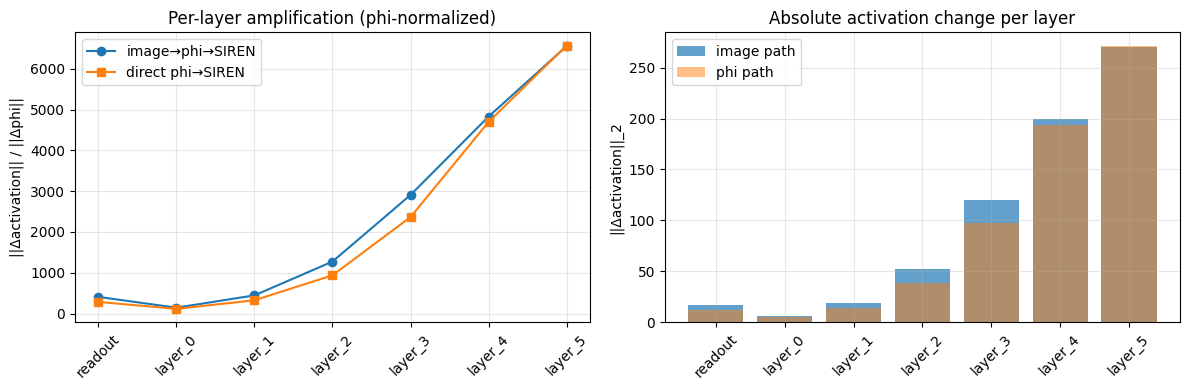

saved /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/perturbation_analysis/vanilla_inner3_makeset_match/layerwise_amplification_idx8138_eps8.csv /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/perturbation_analysis/vanilla_inner3_makeset_match/layerwise_amplification_idx8138_eps8.png


In [6]:
LAYER_EPS = 8  # 8/255 image perturbation for layer study
PHI_PERT_SCALE = 1.0  # match ||dphi|| from image path when possible


def _register_siren_hooks(siren):
    acts = {}

    def make_hook(name):
        def hook(_module, _inp, out):
            acts[name] = out.detach()
        return hook

    handles = []
    for i, layer in enumerate(siren.net):
        handles.append(layer.register_forward_hook(make_hook(f"layer_{i}")))
    handles.append(siren.hidden2rgb.register_forward_hook(make_hook("readout")))
    return acts, handles


def forward_layer_activations(model, phi):
    acts, handles = _register_siren_hooks(model.siren)
    with torch.no_grad():
        _ = model(phi)
    for h in handles:
        h.remove()
    return acts


def layerwise_amplification(model, image_chw, eps, model_args, image_idx, *,
                            functaset_test=None, pert_direction=None, pert_seed=None,
                            phi_pert_scale=1.0):
    pert_direction = PERT_DIRECTION if pert_direction is None else pert_direction
    pert_seed = PERT_SEED if pert_seed is None else pert_seed

    eps_val = eps / 255.0
    delta = make_linf_delta(tuple(image_chw.shape), eps_val, direction=pert_direction, seed=pert_seed)
    x_clean = image_chw.clamp(0, 1)
    x_pert = (x_clean + delta).clamp(0, 1)

    if USE_FUNCTASET_PHI_CLEAN and functaset_test is not None:
        phi_clean = get_functaset_phi(functaset_test, image_idx)
    else:
        phi_clean = fit_phi(model, x_clean)

    init = phi_clean if PERT_INIT_FROM_CLEAN else None
    phi_img_pert = fit_phi(model, x_pert, init_phi=init)

    d_phi_img = phi_img_pert - phi_clean
    phi_norm_img = d_phi_img.norm().item()

    rng = torch.Generator(device=phi_clean.device)
    rng.manual_seed(pert_seed + 999)
    noise = torch.randn(phi_clean.shape, generator=rng, device=phi_clean.device)
    noise = noise / noise.norm() * (phi_norm_img * phi_pert_scale)
    phi_direct = phi_clean + noise

    acts_clean = forward_layer_activations(model, phi_clean)
    acts_img = forward_layer_activations(model, phi_img_pert)
    acts_direct = forward_layer_activations(model, phi_direct)

    delta_eff = (x_pert - x_clean).detach()
    img_l2 = delta_eff.flatten().norm().item()

    rows = []
    for name in sorted(acts_clean.keys(), key=lambda s: (s != "readout", s)):
        dc = acts_clean[name]
        di = acts_img[name]
        dd = acts_direct[name]
        rows.append({
            "layer": name,
            "img_path_act_l2": (di - dc).norm().item(),
            "phi_path_act_l2": (dd - dc).norm().item(),
            "amp_img_over_img_l2": (di - dc).norm().item() / (img_l2 + 1e-12),
            "amp_img_over_phi_l2": (di - dc).norm().item() / (phi_norm_img + 1e-12),
            "amp_phi_over_phi_l2": (dd - dc).norm().item() / (noise.norm().item() + 1e-12),
        })

    df_layers = pd.DataFrame(rows)
    return df_layers, {
        "phi_clean": phi_clean,
        "phi_img_pert": phi_img_pert,
        "phi_direct": phi_direct,
        "phi_norm_img": phi_norm_img,
        "img_l2": img_l2,
    }


idx = IMAGE_INDICES[0]
img0, label0 = cifar_test[idx]
df_layers, layer_meta = layerwise_amplification(
    model, img0, LAYER_EPS, model_args, idx,
    functaset_test=functaset_test,
    pert_seed=PERT_SEED + idx,
    phi_pert_scale=PHI_PERT_SCALE,
)

layer_csv = OUT_ROOT / f"layerwise_amplification_idx{idx}_eps{LAYER_EPS}.csv"
df_layers.to_csv(layer_csv, index=False)
print(f"image idx={idx} label={label0} eps={LAYER_EPS}/255")
print(f"  ||dimage||_2={layer_meta['img_l2']:.4f}  ||dphi(image path)||_2={layer_meta['phi_norm_img']:.4f}")
display(df_layers)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
layers = df_layers["layer"].tolist()
ax[0].plot(layers, df_layers["amp_img_over_phi_l2"], marker="o", label="image→phi→SIREN")
ax[0].plot(layers, df_layers["amp_phi_over_phi_l2"], marker="s", label="direct phi→SIREN")
ax[0].set_ylabel("||Δactivation|| / ||Δphi||")
ax[0].set_title("Per-layer amplification (phi-normalized)")
ax[0].tick_params(axis="x", rotation=45)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].bar(np.arange(len(layers)), df_layers["img_path_act_l2"], alpha=0.7, label="image path")
ax[1].bar(np.arange(len(layers)), df_layers["phi_path_act_l2"], alpha=0.5, label="phi path")
ax[1].set_xticks(np.arange(len(layers)))
ax[1].set_xticklabels(layers, rotation=45)
ax[1].set_ylabel("||Δactivation||_2")
ax[1].set_title("Absolute activation change per layer")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
fig_path = OUT_ROOT / f"layerwise_amplification_idx{idx}_eps{LAYER_EPS}.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("saved", layer_csv, fig_path)

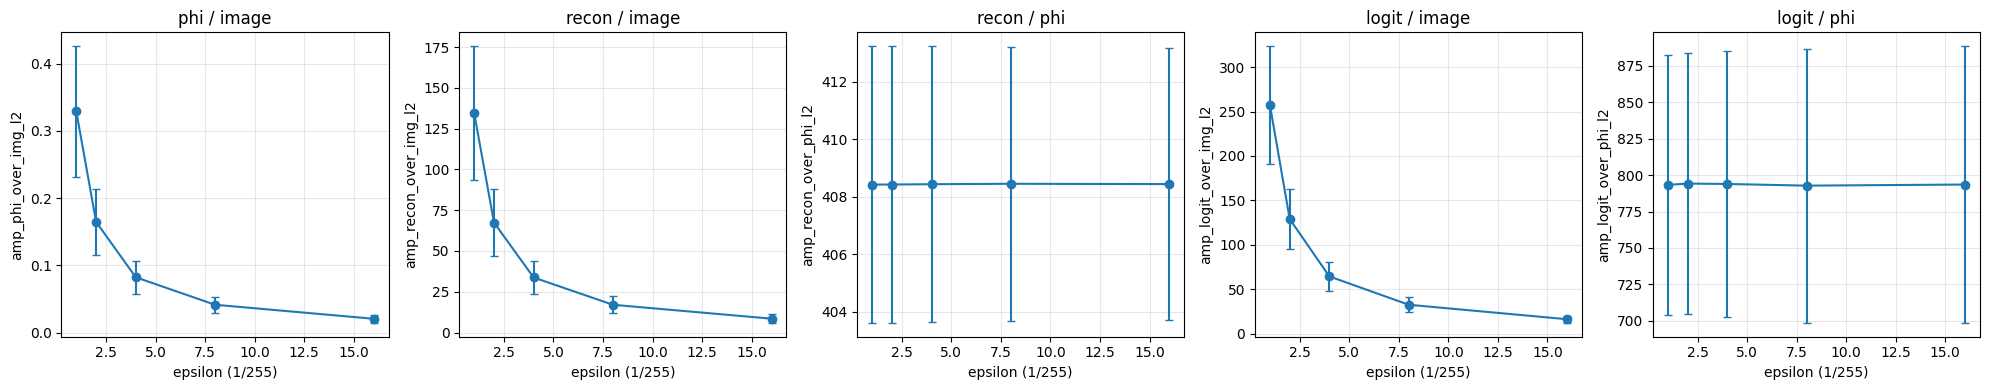

prediction flip rate by eps:
 eps
1     0.5
2     0.5
4     0.5
8     0.5
16    0.5
Name: pred_flip, dtype: float64
saved /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/perturbation_analysis/vanilla_inner3_makeset_match/amplification_vs_eps.png


In [7]:
# 3. Plots: amplification vs epsilon (end-to-end chain)
metrics = [
    ("amp_phi_over_img_l2", "phi / image"),
    ("amp_recon_over_img_l2", "recon / image"),
    ("amp_recon_over_phi_l2", "recon / phi"),
]
if clf is not None:
    metrics.append(("amp_logit_over_img_l2", "logit / image"))
    metrics.append(("amp_logit_over_phi_l2", "logit / phi"))

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, metrics):
    if col not in df_amp.columns:
        continue
    g = df_amp[df_amp["eps"] > 0].groupby("eps")[col].agg(["mean", "std"])
    x = g.index.to_numpy()
    ax.errorbar(x, g["mean"], yerr=g["std"], marker="o", capsize=3)
    ax.set_xlabel("epsilon (1/255)")
    ax.set_ylabel(col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = OUT_ROOT / "amplification_vs_eps.png"
plt.savefig(plot_path, dpi=150)
plt.show()

if clf is not None and "pred_flip" in df_amp.columns:
    flip_rate = df_amp[df_amp["eps"] > 0].groupby("eps")["pred_flip"].mean()
    print("prediction flip rate by eps:\n", flip_rate)

print("saved", plot_path)